In [1]:
#confirming Working Directory
import os
os.getcwd()

'/Users/stevenspero/Desktop/Boston Zoning Project'

In [2]:
#Importing Core Libraries
import geopandas as gpd
import pandas as pd
!pip install matplotlib

In [3]:
#Loading Parcels
parcels = gpd.read_file(
    "parcels_2025_clean/Parcels_2025.shp"
)

print(parcels.shape)
parcels.head()

(98829, 17)


/Users/stevenspero/zoning-env/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(


,MAP_PAR_ID,LOC_ID,POLY_TYPE,MAP_NO,SOURCE,PLAN_ID,BND_CHK,NO_MATCH,TOWN_ID,last_edite,created_us,created_da,last_edi_1,Shape_Leng,Shape_Area,shape_wkt,geometry
0,0107062500,F_799998_2955292,FEE,1,ASSESS,None,NaN,N,35,2024-09-17,NaN,NaT,ASG,0.004526,5.296804e-07,NaN,"POLYGON ((-70.96691 42.35713, -70.96742 42.356..."
1,0107069000,F_810842_2942136,FEE,1,ASSESS,None,NaN,N,35,2024-09-17,NaN,NaT,ASG,0.017822,1.725046e-05,NaN,"POLYGON ((-70.92565 42.31983, -70.9256 42.3193..."
2,0107073100,F_794811_2942749,FEE,1,ASSESS,None,NaN,N,35,2024-09-17,NaN,NaT,ASG,0.001975,2.419783e-07,MULTIPOLYGON (((-70.987074366999934 42.3221099...,"POLYGON ((-70.98707 42.32211, -70.98709 42.321..."
3,0107071000,F_794865_2944326,FEE,1,ASSESS,None,NaN,N,35,2024-09-17,NaN,NaT,ASG,0.020309,2.072160e-05,NaN,"POLYGON ((-70.98517 42.32812, -70.98431 42.327..."
4,0107073000,F_795068_2942369,FEE,1,ASSESS,None,NaN,N,35,2024-09-17,NaN,NaT,ASG,0.009294,5.140685e-06,NaN,"POLYGON ((-70.98584 42.31984, -70.98589 42.319..."


In [4]:
#Quick Sanity Check To Ensure data looks right
parcels.geometry.isna().sum()
parcels.geometry.geom_type.value_counts()

Polygon         98816
MultiPolygon       13
Name: count, dtype: int64

In [5]:
#Loading base zoning districts
zoning = gpd.read_file(
    "boston_zoning_district_clean/Boston_Zoning_Districts.shp"
)

print(zoning.shape)
zoning.head()

(41, 11)


,DISTRICT,STAGE,MAPNO,ARTICLE,VOLUME,SHAPE_STAr,SHAPE_STLe,Shape_Leng,Shape_Area,shape_wkt,geometry
0,Charlestown Neighborhood,Adopted,2E,62,Volume III,0.0,0.0,0.084634,0.000221,None,"POLYGON ((-71.07309 42.38625, -71.07368 42.385..."
1,Leather District,Adopted,1C/1G/1N,44,Volume II,0.0,0.0,0.010478,0.000007,None,"POLYGON ((-71.05715 42.35213, -71.05715 42.352..."
2,Harborpark: North End Waterfront,Adopted,1E-1F,42A,Volume II,0.0,0.0,0.059728,0.000107,None,"POLYGON ((-71.04861 42.37082, -71.04486 42.363..."
3,Cambridge Street North,Adopted,1B/1J/1K/1L,47A,Volume II,0.0,0.0,0.017043,0.000008,None,"POLYGON ((-71.06983 42.36242, -71.06981 42.362..."
4,Harborpark: Charlestown Waterfront,Adopted,2B/2C,42F,Volume II,0.0,0.0,0.127777,0.000284,None,"POLYGON ((-71.07394 42.38456, -71.07375 42.384..."


In [6]:
#Sanity Check
zoning.geometry.isna().sum()
zoning.geometry.geom_type.value_counts()

Polygon         35
MultiPolygon     6
Name: count, dtype: int64

In [7]:
#Making sure CRS match
parcels.crs
zoning.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
#Spacial Join: Assign Zoning to Parcels 
parcels_zoned = gpd.sjoin(
    parcels,
    zoning,
    how="left",
    predicate="intersects"
)

In [9]:
#Checking Results
parcels_zoned.shape
parcels_zoned.columns

Index(['MAP_PAR_ID', 'LOC_ID', 'POLY_TYPE', 'MAP_NO', 'SOURCE', 'PLAN_ID',
       'BND_CHK', 'NO_MATCH', 'TOWN_ID', 'last_edite', 'created_us',
       'created_da', 'last_edi_1', 'Shape_Leng_left', 'Shape_Area_left',
       'shape_wkt_left', 'geometry', 'index_right', 'DISTRICT', 'STAGE',
       'MAPNO', 'ARTICLE', 'VOLUME', 'SHAPE_STAr', 'SHAPE_STLe',
       'Shape_Leng_right', 'Shape_Area_right', 'shape_wkt_right'],
      dtype='str')

In [10]:
#Ensuring Zoning Codes are added to parcels: 
#MAPNO = zoning classification
#ARTICLE + VOLUME = legal rulebook
#DISTRICT = planner-friendly label
parcels_zoned["MAPNO"].value_counts().head()

MAPNO
5A-5E       17328
11A-11E      9770
12           8308
6A/6B/6C     8136
7A-7D        7480
Name: count, dtype: int64

In [11]:
#Handling parcels intersecting multiple zoning districts
#Right now, your join uses intersects, which means:
#Some parcels may match multiple zoning polygons
#This can create duplicate parcel rows
#If you see values > 1, that means a parcel intersects more than one zoning district.
parcels_zoned["MAP_PAR_ID"].value_counts().head()

MAP_PAR_ID
MASSGIS       431
ISLAND         18
0303430000     10
0500812001      4
2005233000      3
Name: count, dtype: int64

In [12]:
#Aggregate zoning info per parcel (production-safe)
#Resolving multi-zoning parcels into a single canonical record
#What this gives you:
#One row per parcel
#Full zoning coverage
#No loss of legal meaning API-ready structure
zoning_agg = (
    parcels_zoned
    .groupby("MAP_PAR_ID")
    .agg({
        "MAPNO": lambda x: sorted({str(v) for v in x if pd.notna(v)}),
        "DISTRICT": lambda x: sorted({str(v) for v in x if pd.notna(v)}),
        "ARTICLE": lambda x: sorted({str(v) for v in x if pd.notna(v)}),
        "VOLUME": lambda x: sorted({str(v) for v in x if pd.notna(v)}),
        "geometry": "first"  # geometry is identical per parcel
    })
    .reset_index()
)

In [13]:
#Sanity Check
zoning_agg.head()

,MAP_PAR_ID,MAPNO,DISTRICT,ARTICLE,VOLUME,geometry
0,0100001000,[3A-3C],[East Boston Neighborhood],[53],[Volume III],"POLYGON ((-71.0325 42.37933, -71.03257 42.3793..."
1,0100002000,[3A-3C],[East Boston Neighborhood],[53],[Volume III],"POLYGON ((-71.03244 42.37935, -71.0325 42.3793..."
2,0100003000,[3A-3C],[East Boston Neighborhood],[53],[Volume III],"POLYGON ((-71.03237 42.37938, -71.03244 42.379..."
3,0100004000,[3A-3C],[East Boston Neighborhood],[53],[Volume III],"POLYGON ((-71.03231 42.3794, -71.03237 42.3793..."
4,0100005000,[3A-3C],[East Boston Neighborhood],[53],[Volume III],"POLYGON ((-71.03216 42.37932, -71.03217 42.379..."


In [14]:
#Normalizing and indexing for AI & APIs
#Convert lists to normalized strings (API-friendly)
#Most APIs and LLMs prefer strings over Python lists:
zoning_agg["MAPNO_STR"] = zoning_agg["MAPNO"].apply(lambda x: ", ".join(x))
zoning_agg["DISTRICT_STR"] = zoning_agg["DISTRICT"].apply(lambda x: ", ".join(x))
zoning_agg["ARTICLE_STR"] = zoning_agg["ARTICLE"].apply(lambda x: ", ".join(x))
zoning_agg["VOLUME_STR"] = zoning_agg["VOLUME"].apply(lambda x: ", ".join(x))

In [15]:
#Add parcel-level feature flags (huge value for users)
zoning_agg["multi_zoning"] = zoning_agg["MAPNO"].apply(lambda x: len(x) > 1)

In [16]:
#Check
zoning_agg["multi_zoning"]

0        False
1        False
2        False
3        False
4        False
         ...  
98505    False
98506    False
98507    False
98508    False
98509     True
Name: multi_zoning, Length: 98510, dtype: bool

In [17]:
#How many fall in multiple zones
zoning_agg["multi_zoning"].value_counts()

multi_zoning
False    97703
True       807
Name: count, dtype: int64

In [18]:
#~0.8% of Boston parcels are multi-zoned
#These are edge cases (waterfronts, overlays, harbor districts, special planning areas)
#Inspecting Actual values:
zoning_agg[zoning_agg["multi_zoning"]].head()

,MAP_PAR_ID,MAPNO,DISTRICT,ARTICLE,VOLUME,geometry,MAPNO_STR,DISTRICT_STR,ARTICLE_STR,VOLUME_STR,multi_zoning
3764,0104126000,"[2A, 3A-3C]","[Boston Harbor, East Boston Neighborhood]","[53, Underlying Zoning]","[Volume I, Volume III]","POLYGON ((-71.03197 42.37214, -71.03197 42.372...","2A, 3A-3C","Boston Harbor, East Boston Neighborhood","53, Underlying Zoning","Volume I, Volume III",True
9272,0203570010,"[2B/2C, 2E]","[Charlestown Neighborhood, Harborpark: Charles...","[42F, 62]","[Volume II, Volume III]","POLYGON ((-71.06048 42.3712, -71.06063 42.3711...","2B/2C, 2E","Charlestown Neighborhood, Harborpark: Charlest...","42F, 62","Volume II, Volume III",True
9273,0203570015,"[2B/2C, 2E]","[Charlestown Neighborhood, Harborpark: Charles...","[42F, 62]","[Volume II, Volume III]","POLYGON ((-71.06052 42.37203, -71.06032 42.371...","2B/2C, 2E","Charlestown Neighborhood, Harborpark: Charlest...","42F, 62","Volume II, Volume III",True
9548,0203963000,"[2B/2C, 2E]","[Charlestown Neighborhood, Harborpark: Charles...","[42F, 62]","[Volume II, Volume III]","POLYGON ((-71.06772 42.37273, -71.06663 42.372...","2B/2C, 2E","Charlestown Neighborhood, Harborpark: Charlest...","42F, 62","Volume II, Volume III",True
9814,0300520000,"[1, 1B]","[Boston Proper, North Station Economic Develop...","[39, Underlying Zoning]","[Volume I, Volume II]","POLYGON ((-71.06592 42.36651, -71.06578 42.366...","1, 1B","Boston Proper, North Station Economic Developm...","39, Underlying Zoning","Volume I, Volume II",True


In [19]:
#Now have:
#Full zoning coverage
#Legal context preserved
#Human-readable + machine-readable fields
#Geometry still intact

In [20]:
#Creating canonical parcel zoning table:
final_parcels = zoning_agg[[
    "MAP_PAR_ID",
    "MAPNO_STR",
    "DISTRICT_STR",
    "ARTICLE_STR",
    "VOLUME_STR",
    "multi_zoning",
    "geometry"
]].copy()

#This gives you:
#One row per parcel
#Clean strings for APIs / LLMs
#A boolean complexity flag
#Geometry preserved

In [21]:
# Define primary (dominant) zoning code
final_parcels["primary_mapno"] = (
    final_parcels["MAPNO_STR"]
    .fillna("")
    .apply(lambda x: x.split(", ")[0] if x else None)
)

In [22]:
# FINAL geometry + CRS normalization (do this once)
final_parcels = final_parcels.set_geometry("geometry")

if final_parcels.crs is None:
    final_parcels = final_parcels.set_crs(epsg=4326)
elif final_parcels.crs.to_epsg() != 4326:
    final_parcels = final_parcels.to_crs(epsg=4326)

# force rebuild (extra safe)
final_parcels.sindex

In [23]:
# Step 7A: Define a primary zoning code (first = most common / dominant)
final_parcels["primary_mapno"] = final_parcels["MAPNO_STR"].apply(
    lambda x: x.split(", ")[0]
)
#Why this matters:

#Frontends need a single zoning label
#LLMs prefer one “main answer” + caveats
#Developers can filter easily

In [24]:
#Add a zoning “complexity score”
final_parcels["zoning_count"] = final_parcels["MAPNO_STR"].str.count(",") + 1

In [25]:
# Ensure CRS is lat/lon BEFORE spatial queries
if final_parcels.crs is None:
    final_parcels = final_parcels.set_crs(epsg=4326)
elif final_parcels.crs.to_epsg() != 4326:
    final_parcels = final_parcels.to_crs(epsg=4326)

In [26]:
# Adding a user-facing explanation string
final_parcels["zoning_summary"] = final_parcels.apply(
    lambda r: (
        f"Parcel is governed by {r['MAPNO_STR']} under {r['ARTICLE_STR']} "
        f"({r['VOLUME_STR']})."
        + (" Multiple zoning districts apply." if r["multi_zoning"] else "")
    ),
    axis=1
)
#Now your API / AI can literally say:
#“This parcel is governed by 2A and 3A-3C under Article 53 (Volume III). Multiple zoning districts apply.”

In [27]:
#Parcel-ID lookup
def get_zoning_by_parcel_id(parcel_id: str):
    row = final_parcels[final_parcels["MAP_PAR_ID"] == parcel_id]
    if row.empty:
        return None
    return row.iloc[0].to_dict()

In [28]:
final_parcels.columns


Index(['MAP_PAR_ID', 'MAPNO_STR', 'DISTRICT_STR', 'ARTICLE_STR', 'VOLUME_STR',
       'multi_zoning', 'geometry', 'primary_mapno', 'zoning_count',
       'zoning_summary'],
      dtype='str')

In [29]:
def serialize_parcel(row) -> dict:
    return {
        # Identifiers
        "parcel_id": str(row["MAP_PAR_ID"]) if row["MAP_PAR_ID"] is not None else None,

        # Zoning fields
        "primary_zoning": (
            str(row["primary_mapno"]) if row["primary_mapno"] is not None else None
        ),
        "all_zoning_codes": str(row["MAPNO_STR"]) if row["MAPNO_STR"] is not None else "",
        "districts": str(row["DISTRICT_STR"]) if row["DISTRICT_STR"] is not None else "",
        "article": str(row["ARTICLE_STR"]) if row["ARTICLE_STR"] is not None else "",
        "volume": str(row["VOLUME_STR"]) if row["VOLUME_STR"] is not None else "",

        # Flags & counts (STRICT typing)
        "multi_zoning": bool(row["multi_zoning"]),
        "zoning_count": int(row["zoning_count"]) if row["zoning_count"] is not None else 0,

        # Human-readable explanation
        "summary": str(row.get("zoning_summary")) if row.get("zoning_summary") else "",

        # Geometry (GeoJSON-safe)
        "geometry": (
            row["geometry"].__geo_interface__
            if row["geometry"] is not None
            else None
        ),
    }

In [30]:
# Sanity test serialization
row = final_parcels.iloc[0]
serialize_parcel(row)

{'parcel_id': '0100001000',
 'primary_zoning': '3A-3C',
 'all_zoning_codes': '3A-3C',
 'districts': 'East Boston Neighborhood',
 'article': '53',
 'volume': 'Volume III',
 'multi_zoning': False,
 'zoning_count': 1,
 'summary': 'Parcel is governed by 3A-3C under 53 (Volume III).',
 'geometry': {'type': 'Polygon',
  'coordinates': (((-71.03250248699999, 42.37932830200003),
    (-71.03257402199995, 42.379300888000046),
    (-71.03267141199996, 42.37944519100006),
    (-71.03260433999998, 42.37947022800006),
    (-71.03250248699999, 42.37932830200003)),)}}

In [31]:
#Location lookup
#With this can answer:“What zoning applies at 42.3721, -71.0605?”
from shapely.geometry import Point

def get_zoning_by_latlon(lat: float, lon: float):
    point = Point(lon, lat)

    # Use spatial index first (FAST)
    possible_matches_index = list(
        final_parcels.sindex.intersection(point.bounds)
    )
    possible_matches = final_parcels.iloc[possible_matches_index]

    # Precise geometry check (SAFE)
    match = possible_matches[possible_matches.geometry.covers(point)
]

    if match.empty:
        return None

    return match.iloc[0].to_dict()

In [32]:
# Batch serialize all parcels
serialized_parcels = final_parcels.apply(
    lambda r: serialize_parcel(r),
    axis=1
).tolist()


In [33]:
# Schema definition for serialized parcel zoning objects
# This is NOT data — it is metadata for consumers (API, frontend, LLMs)

PARCEL_ZONING_SCHEMA = {
    "parcel_id": "string",
    "primary_zoning": "string | null",
    "all_zoning_codes": "string",
    "districts": "string",
    "article": "string",
    "volume": "string",
    "multi_zoning": "boolean",
    "zoning_count": "number",
    "summary": "string"
}

In [34]:
# ===== Schema Validator =====

EXPECTED_FIELDS = set(PARCEL_ZONING_SCHEMA.keys()) | {"geometry"}

def validate_parcel_schema(parcel: dict):
    missing = EXPECTED_FIELDS - parcel.keys()
    extra = parcel.keys() - EXPECTED_FIELDS

    if missing:
        raise ValueError(f"Missing fields in parcel output: {missing}")

    if extra:
        raise ValueError(f"Unexpected fields in parcel output: {extra}")

    # Type checks (v1.0.0 contract)
    assert isinstance(parcel["parcel_id"], (str, type(None)))
    assert isinstance(parcel["primary_zoning"], (str, type(None)))
    assert isinstance(parcel["all_zoning_codes"], str)
    assert isinstance(parcel["districts"], str)
    assert isinstance(parcel["article"], str)
    assert isinstance(parcel["volume"], str)
    assert isinstance(parcel["multi_zoning"], bool)
    # 🔒 STRICT enforcement for zoning_count (DO THIS HERE)
    if not isinstance(parcel["zoning_count"], int):
        raise TypeError("zoning_count must be int")

    assert isinstance(parcel["summary"], str)

    if parcel["geometry"] is not None and parcel["geometry"].get("type") not in {"Polygon", "MultiPolygon"}:
        raise ValueError("Invalid geometry type")


In [35]:
# Enforce schema on entire dataset (fail fast)
for p in serialized_parcels:
    validate_parcel_schema(p)

In [36]:
#Exporting
#File is now:
#frontend-ready
#API-ready
#LLM-friendly

import json

with open("boston_parcels_zoning.json", "w") as f:
    json.dump(serialized_parcels, f)

In [37]:
# ===== Schema & Versioning (LOCKED) =====

SCHEMA_NAME = "boston_parcel_zoning"
SCHEMA_VERSION = "1.0.0"

SCHEMA_COMPATIBILITY_RULES = {
    "v1.x": "Backward compatible only (additive changes allowed)",
    "v2.0": "Breaking changes allowed (field removal / rename / semantic change)"
}

SCHEMA_STATUS = "STABLE"  # v1.0.0 is locked

In [38]:
from datetime import datetime, timezone

geojson = {
    "meta": {
        "schema_name": SCHEMA_NAME,
        "schema_version": SCHEMA_VERSION,
        "schema_status": SCHEMA_STATUS,
        "compatibility": SCHEMA_COMPATIBILITY_RULES,
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "crs": "EPSG:4326",
        "entity": "parcel",
        "source": "Boston Zoning Code"
    },
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": p["geometry"],
            "properties": {k: v for k, v in p.items() if k != "geometry"}
        }
        for p in serialized_parcels
        if p["geometry"] is not None
    ]
}

with open("boston_parcels_zoning.geojson", "w") as f:
    json.dump(geojson, f, indent=2)


In [39]:
# ===== JSON Schema Export (machine-readable contract) =====
JSON_SCHEMA_V1 = {
    "$schema": "https://json-schema.org/draft/2020-12/schema",
    "$id": f"https://schemas.example.com/{SCHEMA_NAME}/{SCHEMA_VERSION}.json",
    "title": "Boston Parcel Zoning",
    "description": "Canonical zoning schema for Boston parcels",
    "type": "object",
    "required": [
        "parcel_id",
        "primary_zoning",
        "all_zoning_codes",
        "districts",
        "article",
        "volume",
        "multi_zoning",
        "zoning_count",
        "summary"
    ],
    "properties": {
        "parcel_id": {
            "type": ["string", "null"]
        },
        "primary_zoning": {
            "type": ["string", "null"]
        },
        "all_zoning_codes": {
            "type": "string"
        },
        "districts": {
            "type": "string"
        },
        "article": {
            "type": "string"
        },
        "volume": {
            "type": "string"
        },
        "multi_zoning": {
            "type": "boolean"
        },
        "zoning_count": {
            "type": "integer",
            "minimum": 0
        },
        "summary": {
            "type": "string"
        },
        "geometry": {
            "type": ["object", "null"],
            "description": "GeoJSON geometry object"
        }
    },
    "additionalProperties": False
}


In [40]:
# Export JSON Schema to disk
with open("boston_parcel_zoning.schema.json", "w") as f:
    json.dump(JSON_SCHEMA_V1, f, indent=2)

In [41]:
SCHEMA_METADATA = {
    "schema_name": "boston_parcel_zoning",
    "schema_version": "1.0.0",
    "fields": PARCEL_ZONING_SCHEMA
}

In [42]:
# Notebook complete – freeze final outputs
assert "primary_mapno" in final_parcels.columns
assert "zoning_summary" in final_parcels.columns
assert final_parcels.geometry.notnull().any()

In [43]:
EXPECTED_FIELDS = {
    "parcel_id",
    "primary_zoning",
    "all_zoning_codes",
    "districts",
    "article",
    "volume",
    "multi_zoning",
    "zoning_count",
    "summary",
    "geometry",
}

sample = serialized_parcels[0]
assert EXPECTED_FIELDS.issubset(sample.keys())

In [44]:
pip install jsonschema

Note: you may need to restart the kernel to use updated packages.


In [45]:
from jsonschema import Draft202012Validator

# Compile schema once (fast + reusable)
schema_validator = Draft202012Validator(JSON_SCHEMA_V1)

# Validate entire dataset (fail fast)
for i, parcel in enumerate(serialized_parcels):
    errors = sorted(schema_validator.iter_errors(parcel), key=lambda e: e.path)
    if errors:
        raise ValueError(
            f"Schema validation failed for parcel index {i}:\n" +
            "\n".join(error.message for error in errors)
        )

print("✅ All parcels conform to JSON Schema v1.0.0")


✅ All parcels conform to JSON Schema v1.0.0


In [46]:
import geopandas as gpd
gdf = gpd.read_file("parcels_2025_clean/Parcels_2025.shp")
print(gdf.columns)

Index(['MAP_PAR_ID', 'LOC_ID', 'POLY_TYPE', 'MAP_NO', 'SOURCE', 'PLAN_ID',
       'BND_CHK', 'NO_MATCH', 'TOWN_ID', 'last_edite', 'created_us',
       'created_da', 'last_edi_1', 'Shape_Leng', 'Shape_Area', 'shape_wkt',
       'geometry'],
      dtype='str')


/Users/stevenspero/zoning-env/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(


In [47]:
parcel_id = "YOUR_TEST_ID_HERE"

parcel = gdf[gdf["MAP_PAR_ID"] == parcel_id]

parcel

,MAP_PAR_ID,LOC_ID,POLY_TYPE,MAP_NO,SOURCE,PLAN_ID,BND_CHK,NO_MATCH,TOWN_ID,last_edite,created_us,created_da,last_edi_1,Shape_Leng,Shape_Area,shape_wkt,geometry


In [48]:
gdf["MAP_PAR_ID"].head()

0    0107062500
1    0107069000
2    0107073100
3    0107071000
4    0107073000
Name: MAP_PAR_ID, dtype: str

In [49]:
print(final_parcels.crs)

EPSG:4326


In [50]:
row = final_parcels[final_parcels["MAP_PAR_ID"] == "0107069000"].iloc[0]
print(row["geometry"].geom_type)

Polygon


In [51]:
from shapely.ops import transform
import pyproj

geom = row["geometry"]

project = pyproj.Transformer.from_crs(
    "EPSG:4326",
    "EPSG:26986",
    always_xy=True
).transform

geom_projected = transform(project, geom)

print("Area in sqm:", geom_projected.area)
print("Area in sqft:", geom_projected.area * 10.7639)


Area in sqm: 157948.07704343303
Area in sqft: 1700137.3064878087


<Axes: >

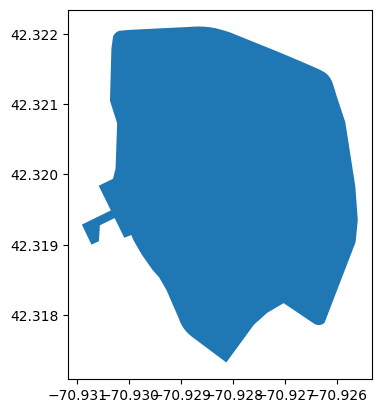

In [52]:
final_parcels[
    final_parcels["MAP_PAR_ID"] == "0107069000"
].plot()

In [53]:
!python zba_pipeline/build_dataset.py

Traceback (most recent call last):
  File "/Users/stevenspero/Desktop/Boston Zoning Project/zba_pipeline/build_dataset.py", line 5, in <module>
    from zba_pipeline.extract_text import extract_pdf_text
ModuleNotFoundError: No module named 'zba_pipeline'


In [54]:
from zba_pipeline.build_dataset import main
main()

Dataset saved to zba_cases_dataset.csv


In [55]:
import sys
import os

project_root = os.path.abspath(".")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: /Users/stevenspero/Desktop/Boston Zoning Project


In [56]:
from zba_pipeline.build_dataset import main
main()

Dataset saved to zba_cases_dataset.csv


In [57]:
import os
print(os.getcwd())


/Users/stevenspero/Desktop/Boston Zoning Project


In [58]:
from zba_pipeline.build_dataset import main
main()

Dataset saved to zba_cases_dataset.csv


In [59]:
!pip install geopandas matplotlib pandas pdfplumber

In [12]:
import pandas as pd

df = pd.read_csv("zba_cases_dataset.csv")

print(df.shape)
df.head()

EmptyDataError: No columns to parse from file

In [13]:
!pip install geopandas pandas matplotlib pdfplumber

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import glob
import os
import sys

In [14]:
project_root = os.path.abspath(".")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root:", project_root)


Project root: /Users/stevenspero/Desktop/Boston Zoning Project


In [15]:
import importlib
import zba_pipeline.parse_cases as pc

importlib.reload(pc)

<module 'zba_pipeline.parse_cases' from '/Users/stevenspero/Desktop/Boston Zoning Project/zba_pipeline/parse_cases.py'>

In [19]:
from zba_pipeline.extract_text import extract_pdf_text
from zba_pipeline.parse_cases import split_cases

pdfs = glob.glob("pdfs/*.pdf")

sample = pdfs[0]
text = extract_pdf_text(sample)

cases = split_cases(text)

print("Number of cases found:", len(cases))
print(cases[0][:300])

ImportError: cannot import name 'split_cases' from 'zba_pipeline.parse_cases' (/Users/stevenspero/Desktop/Boston Zoning Project/zba_pipeline/parse_cases.py)

In [17]:
from zba_pipeline.build_dataset import main
main()

ImportError: cannot import name 'split_cases' from 'zba_pipeline.parse_cases' (/Users/stevenspero/Desktop/Boston Zoning Project/zba_pipeline/parse_cases.py)

In [69]:
from zba_pipeline.parse_cases import parse_case

sample_case = cases[0]

parsed = parse_case(sample_case)

print(parsed)

{'case_number': 'BOA1775242', 'address': '1 Hartlawn Road, Ward 20', 'decision': 'Unknown'}


In [20]:
print("TOTAL ROWS COLLECTED:", len(rows))
print("SAMPLE ROW:", rows[0] if rows else "NO ROWS")

NameError: name 'rows' is not defined

In [26]:
!python zba_pipeline/build_dataset.py

PDF FILES FOUND: 0
TOTAL CASES: 0
Dataset saved to zba_cases_dataset.csv


In [27]:
import os
print("CURRENT WORKING DIRECTORY:", os.getcwd())

CURRENT WORKING DIRECTORY: /Users/stevenspero/Desktop/Boston Zoning Project


In [1]:
!python zba_pipeline/build_dataset.py

CURRENT WORKING DIRECTORY: /Users/stevenspero/Desktop/Boston Zoning Project
PDF FILES FOUND: 248
Processing pdfs/Decision Detail Filed December 26th, 2025.pdf...
Processing pdfs/Decision Detail Filed July 29th, 2022.pdf...
Processing pdfs/Decision Detail Filed June 30th, 2023.pdf...
Processing pdfs/Decision Detail Filed March 24th, 2023.pdf...
Processing pdfs/Decision Detail Filed August 2nd, 2024.pdf...
Processing pdfs/Decision Detail Filed November 14th, 2025.pdf...
Processing pdfs/Decision Detail Filed December 22nd 2023.pdf...
Processing pdfs/Decision Detail Filed July 7th, 2023.pdf...
Processing pdfs/Decision Detail Filed September 2nd, 2022.pdf...
Processing pdfs/Decision Detail Filed October 27th, 2023.pdf...
Processing pdfs/Decision Detail Filed February 14th, 2025.pdf...
Processing pdfs/Decision Detail Filed February 6th, 2026.pdf...
Processing pdfs/Decision Detail Filed April 1st, 2022.pdf...
Processing pdfs/Decision Detail Filed May 20th, 2024.pdf...
Processing pdfs/Decision

In [2]:
import pandas as pd

df = pd.read_csv("zba_cases_dataset.csv")
print(len(df))
df.head()

328


,case_number,address,decision
0,BOA1775242,"1 Hartlawn Road, Ward 20",SUSTAINED
1,BOA1689097,"18 Robeson Street, Ward 11",SUSTAINED
2,BOA1689101,"18R Robeson Street, Ward 11",SUSTAINED
3,BOA1653647,"38 Fenway, Ward 4",SUSTAINED
4,BOA1776813,"70 Burbank Street, Ward 4",SUSTAINED


In [3]:
df["decision"].value_counts()

decision
SUSTAINED    313
DENIED         2
Name: count, dtype: int64

In [1]:
!python zba_pipeline/build_dataset.py

CURRENT WORKING DIRECTORY: /Users/stevenspero/Desktop/Boston Zoning Project
PDF FILES FOUND: 248
Processing pdfs/Decision Detail Filed December 26th, 2025.pdf...
Processing pdfs/Decision Detail Filed July 29th, 2022.pdf...
Processing pdfs/Decision Detail Filed June 30th, 2023.pdf...
Processing pdfs/Decision Detail Filed March 24th, 2023.pdf...
Processing pdfs/Decision Detail Filed August 2nd, 2024.pdf...
Processing pdfs/Decision Detail Filed November 14th, 2025.pdf...
Processing pdfs/Decision Detail Filed December 22nd 2023.pdf...
Processing pdfs/Decision Detail Filed July 7th, 2023.pdf...
Processing pdfs/Decision Detail Filed September 2nd, 2022.pdf...
Processing pdfs/Decision Detail Filed October 27th, 2023.pdf...
Processing pdfs/Decision Detail Filed February 14th, 2025.pdf...
Processing pdfs/Decision Detail Filed February 6th, 2026.pdf...
Processing pdfs/Decision Detail Filed April 1st, 2022.pdf...
Processing pdfs/Decision Detail Filed May 20th, 2024.pdf...
Processing pdfs/Decision

In [2]:
import pandas as pd

df = pd.read_csv("zba_cases_dataset.csv")

print(len(df))
df["decision"].value_counts()

328


decision
APPEAL SUSTAINED    311
DENIED               12
GRANTED               5
Name: count, dtype: int64

In [3]:
!python zba_pipeline/build_dataset.py

CURRENT WORKING DIRECTORY: /Users/stevenspero/Desktop/Boston Zoning Project
PDF FILES FOUND: 248
Processing pdfs/Decision Detail Filed December 26th, 2025.pdf...
Processing pdfs/Decision Detail Filed July 29th, 2022.pdf...
Processing pdfs/Decision Detail Filed June 30th, 2023.pdf...
Processing pdfs/Decision Detail Filed March 24th, 2023.pdf...
Processing pdfs/Decision Detail Filed August 2nd, 2024.pdf...
Processing pdfs/Decision Detail Filed November 14th, 2025.pdf...
Processing pdfs/Decision Detail Filed December 22nd 2023.pdf...
Processing pdfs/Decision Detail Filed July 7th, 2023.pdf...
Processing pdfs/Decision Detail Filed September 2nd, 2022.pdf...
Processing pdfs/Decision Detail Filed October 27th, 2023.pdf...
Processing pdfs/Decision Detail Filed February 14th, 2025.pdf...
Processing pdfs/Decision Detail Filed February 6th, 2026.pdf...
Processing pdfs/Decision Detail Filed April 1st, 2022.pdf...
Processing pdfs/Decision Detail Filed May 20th, 2024.pdf...
Processing pdfs/Decision

In [4]:
import pandas as pd

df = pd.read_csv("zba_cases_dataset.csv")

print("Total cases:", len(df))
df["decision"].value_counts()

Total cases: 332


decision
APPEAL SUSTAINED    311
DENIED               14
GRANTED               7
Name: count, dtype: int64

In [3]:
!python zba_pipeline/build_dataset.py

Working directory: /Users/stevenspero/Desktop/Boston Zoning Project
PDF files found: 248
Processing: pdfs/Decision Detail Filed December 26th, 2025.pdf
Processing: pdfs/Decision Detail Filed July 29th, 2022.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed June 30th, 2023.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed March 24th, 2023.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed August 2nd, 2024.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed November 14th, 2025.pdf
Processing: pdfs/Decision Detail Filed December 22nd 2023.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed July 7th, 2023.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed September 2nd, 2022.pdf
Low case count, attempting recovery...
Processing: pdfs/Decision Detail Filed October 27th, 2023.pdf
Low case count, attempting re

In [3]:
import pandas as pd
df = pd.read_csv("zba_cases_dataset.csv")

print("Total cases:", len(df))
print(df.isnull().mean())

Total cases: 520
case_number            0.000000
permit_number          0.365385
address                0.167308
ward                   0.103846
decision               0.000000
zoning_sections        0.880769
project_description    0.480769
dtype: float64


In [4]:
df["decision"].value_counts()

decision
APPEAL SUSTAINED    314
GRANTED              99
UNKNOWN              85
DENIED               22
Name: count, dtype: int64

In [5]:
import glob
len(glob.glob("pdfs/*.pdf"))

248

In [1]:
import pandas as pd

df = pd.read_csv("zba_cases_dataset.csv")

print("Total cases:", len(df))
print(df["decision"].value_counts())

Total cases: 520
decision
APPEAL SUSTAINED    314
GRANTED              99
UNKNOWN              85
DENIED               22
Name: count, dtype: int64


In [1]:
!pip install pymupdf pytesseract pillow pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 18.1 MB/s  0:00:01 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pymupdf]━━━ 1/2 [pymupdf]


In [ ]:
!python zba_pipeline/build_dataset.py

In [ ]:
python zba_pipeline/build_dataset.py

In [1]:
import os
import hashlib

PDF_FOLDER = "pdfs"  # change if needed

def file_hash(filepath):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        while chunk := f.read(8192):
            hasher.update(chunk)
    return hasher.hexdigest()


def remove_duplicates(folder):
    seen_hashes = {}
    duplicates = []

    for filename in os.listdir(folder):
        if not filename.lower().endswith(".pdf"):
            continue

        path = os.path.join(folder, filename)
        h = file_hash(path)

        if h in seen_hashes:
            duplicates.append(path)
        else:
            seen_hashes[h] = path

    print(f"Found {len(duplicates)} duplicate files")

    for dup in duplicates:
        print(f"Removing: {dup}")
        os.remove(dup)


if __name__ == "__main__":
    remove_duplicates(PDF_FOLDER)

Found 8 duplicate files
Removing: pdfs/Decision Detail Filed August 5th, 2022 (1).pdf
Removing: pdfs/Decision Detail Filed November 29th, 2024 (1).pdf
Removing: pdfs/Decision Detail Filed September 30th, 2022.pdf
Removing: pdfs/Decision Detail Filed December 9th, 2022.pdf
Removing: pdfs/decisions signed January 22, 2021.pdf
Removing: pdfs/Decision Detail Filed March 18th, 2022.pdf
Removing: pdfs/Decision Detail filed May 6th, 2022 (1).pdf
Removing: pdfs/Decision Detail Filed February 4th, 2022.pdf


In [1]:
import pandas as pd

df = pd.read_csv("zba_cases_dataset.csv")

print("Total cases:", len(df))
df.head()

Total cases: 16962


,case_number,address,applicant,zoning,decision,raw_text,source_pdf
0,BOA1775242,70431 \nAPPEAL SUSTAINED \nIn reference to the...,NaN,"Section 8, Article 56, Section 8, Article 56, ...",GRANTED,BOA1775242 \nPERMIT #ERT1770431 \nAPPEAL SUST...,"Decision Detail Filed December 26th, 2025.pdf"
1,BOA-1775242,00 \nCity of Boston \nBoard of Appeal \nDECISI...,NaN,"Article 7, Section 7",APPROVED,BOA-1775242 and made a part of this record. \...,"Decision Detail Filed December 26th, 2025.pdf"
2,BOA1775242,NaN,NaN,NaN,GRANTED,"BOA1775242 \nDate of Hearing: December 9, 202...","Decision Detail Filed December 26th, 2025.pdf"
3,BOA1689097,84090 \nAPPEAL SUSTAINED \nWITH PROVISOS \nIn ...,NaN,"Section 8, Article 55, Section 41",GRANTED,BOA1689097 \nPERMIT #ATL1684090 \nAPPEAL SUST...,"Decision Detail Filed December 26th, 2025.pdf"
4,BOA-1689097,00 \nI \nCity of Boston \nBoard of Appeal \nDE...,NaN,"Article 55, Section 41, Article 55, Section 41...",APPROVED,"BOA-1689097 , and made a part of this record. ...","Decision Detail Filed December 26th, 2025.pdf"


In [2]:
df["decision"].value_counts()

decision
GRANTED             7303
APPROVED            4983
REFUSED             3185
DENIED               541
REJECTED             139
APPEAL DENIED         64
APPEAL SUSTAINED       1
Name: count, dtype: int64

In [3]:
df.sample(5)

,case_number,address,applicant,zoning,decision,raw_text,source_pdf
2292,BOA-1249024,00\n\nCity of Boston\nBoard of Appeal\n\nDECIS...,NaN,NaN,APPROVED,BOA-1249024 and made a part of this record.\n...,"Decision Detail Filed June 17th, 2022.pdf"
13033,BOA1121558,NaN,NaN,"Article 7, Section 7",APPROVED,"BOA1121558 \n\nDate of Hearing: February 2, 20...","Decision detailes filed on April 16, 2021 fina..."
15950,BOA1595840,96636\nAPPEAL SUSTAINED\n\nIn reference to the...,NaN,"Section 8, Article 67, Section 9",GRANTED,BOA1595840 \nPERMIT # ALT1496636\nAPPEAL SUSTA...,"Decision Detail Filed July 19th, 2024.pdf"
558,BOA1406531,NaN,NaN,NaN,NaN,"BOA1406531 \n\nDate of Hearing: May 9, 2023\nP...","Decision Detail Filed July 7th, 2023.pdf"
10424,BOA-1622321,757 Dudley Street,NaN,"Article 65, Section 41, Article 65, Section 42...",REFUSED,BOA-1622321 \n\nDate of Hearing 10/08/2024\nAp...,"Decision Detail Filed October 25th, 2024 (1).pdf"


In [4]:
df.isnull().mean()

case_number    0.000590
address        0.243426
applicant      0.999882
zoning         0.409857
decision       0.043981
raw_text       0.000000
source_pdf     0.000000
dtype: float64

In [5]:
print(df.iloc[0]["raw_text"][:1000])

BOA1775242  
PERMIT #ERT1770431 
APPEAL SUSTAINED 
In reference to the appeal of 
Antonio Ferrara 
Concerning the premises located at 
1 Hartlawn Road, Ward 20 
For relief from the provisions of the Zoning Act, Ch. 665, Acts of 1956, as amended, in this specific case, I beg 
to advise that the petition has been granted. 
The Board's decision has been filed in the office of the Commissioner of the lnspectional Services Department, 
1010 Massachusetts Avenue, Fourth Floor, Boston, MA 02118, and is open for public inspection. A copy of the 
decision is available on the Board's website at https://www.boston.gov/departments/inspectional-
services/zoninq-board-appeal-decisions. The decisions are organized by filing date. 
Date of filing of this decision with the lnspectional Services Department was 12/26/2025. The relief granted 
by this decision expires on 12/26/2027, and must be exercised or extended for good cause only on or 
before this date. Requests for extensions must be submitted in 

In [6]:
df = df.drop_duplicates(subset=["case_number", "source_pdf"])
print("After dedup:", len(df))

After dedup: 7624


In [7]:
df["decision"] = df["decision"].replace({
    "APPROVED": "GRANTED"
})

In [8]:
print("Cases:", len(df))
print("\nDecision Breakdown:\n", df["decision"].value_counts())
print("\nMissing %:\n", df.isnull().mean())

Cases: 7624

Decision Breakdown:
 decision
GRANTED             6729
DENIED               443
REFUSED              364
REJECTED              26
APPEAL DENIED          9
APPEAL SUSTAINED       1
Name: count, dtype: int64

Missing %:
 case_number    0.001049
address        0.070042
applicant      1.000000
zoning         0.418284
decision       0.006821
raw_text       0.000000
source_pdf     0.000000
dtype: float64


In [9]:
df["decision_binary"] = df["decision"].apply(lambda x: 1 if x == "GRANTED" else 0)

df.groupby("zoning")["decision_binary"].mean().sort_values(ascending=False)

zoning
Section 8, Article 51, Section 8, Article 51, Section 9, Article 51, Section 9, Article 51, Section 9, Article 51, Section 56                                                                                     1.0
Section 8, Article 53, Section 53, Article 6                                                                                                                                                                      1.0
Section 8, Article 53, Section 57                                                                                                                                                                                 1.0
Section 8, Article 53, Section 56, Article 53, Section 9, Article 53, Section 9, Article 53, Section 9, Article 53, Section 9, Article 53, Section 9, Article 53, Section 9, Article 27, Article 52, Section 8    1.0
Section 8, Article 53, Section 56, Article 53, Section 9, Article 53, Section 9, Article 53, Section 9, Article 53, Section 9, Article 53

In [1]:
import geopandas as gpd

gdf = gpd.read_file("parcels_2025_clean/Parcels_2025.shp")
print(gdf.columns)

Index(['MAP_PAR_ID', 'LOC_ID', 'POLY_TYPE', 'MAP_NO', 'SOURCE', 'PLAN_ID',
       'BND_CHK', 'NO_MATCH', 'TOWN_ID', 'last_edite', 'created_us',
       'created_da', 'last_edi_1', 'Shape_Leng', 'Shape_Area', 'shape_wkt',
       'geometry'],
      dtype='object')


/Users/stevenspero/zoning-env/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
